In [1]:
import pandas as pd
import utils
from config import Config
from preprocessing import cleaning
from analysis import plot_coordinates

Загрузка данных

In [2]:
train = utils.load_train_data()
test = utils.load_test_data()

/home/gshjis/Python_projects/apartment_rent_data/paсkages/utils/utils/data_loader.py:16: DtypeWarning: Columns (0: address) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv(train_path, encoding="windows-1252", sep=";")


Колонка curency и pricetype неинформативна

In [3]:
train.drop(columns=["currency", "price_type", "pets_allowed"], inplace=True)

Проверка совпадения городов в тренировочной и тестовой выборках

In [4]:
a = set(train["cityname"].unique()) & set(train["cityname"].unique())
b = set(train["cityname"].unique())
print("Cityname intersection power ", len(a))
print("Cityname intersection train power ", len(b))


Cityname intersection power  2980
Cityname intersection train power  2980


Все города из тестовой выборки присутствуют в тренировочной

## 📊 Анализ редких категорий

Среди категориальных признаков `['category', 'fee', 'cityname', 'source']` наблюдаются редкие категории. Для дальнейшего анализа предлагается **5%** из каждой категории объединить в категорию **`other`**.

In [5]:
train = cleaning(train, ['category', 'fee', 'source'])

category: 6 редких категорий заменено на 'other'
fee: 1 редких категорий заменено на 'other'
source: 23 редких категорий заменено на 'other'


Анализ числовых парметров объектов выборки

In [6]:
# utils.get_numeric_stats(train, ["amenities", "title", "id", "address", "body", "bathrooms"],n_bins=30)  

## 📈 Анализ распределений числовых признаков

### 🎯 **Ключевые наблюдения:**

#### 1. **Цена аренды (`price`)**
- **Среднее значение**: \$1527.06 (±904.25)
- **95% ДИ**: [\$1521.44, \$1532.68]
- **Характер распределения**: выраженное **экспоненциальное**
- **Интерпретация**: Большинство объектов сосредоточены в диапазоне \$600-\$2000, с длинным "хвостом" элитного жилья до \$5000+

#### 2. **Площадь (`square_feet`)**
- **Среднее значение**: 956.43 (±417.57) кв. футов
- **95% ДИ**: [953.84, 959.03]
- **Характер распределения**: **экспоненциальное**, менее выраженное
- **Интерпретация**: Преобладают компактные квартиры (500-1000 кв. футов)

#### 3. **Количество спален (`bedrooms`)**
- **Среднее значение**: 1.73 (±0.75)
- **95% ДИ**: [1.72, 1.73]
- **Характер распределения**: **скошенное**, близкое к экспоненциальному
- **Интерпретация**: Доминируют 1-2 спальни, студии и 3+ встречаются реже

### 📌 **Выводы**
- Экспоненциальный характер распределений указывает на **неравномерность рынка**: массовое бюджетное жилье + редкие элитные объекты
- Узкие доверительные интервалы (благодаря выборке 10K) обеспечивают **высокую точность оценок**
- Для подтверждения типа распределений могут быть применены **статистические тесты**

Анализ категориальных статистик выборки

In [7]:
# utils.get_categorical_stats(train, ["amenities", "title", "id", "address", "body", "bathrooms"])  

Объединим города и их штат. Поскольку есть города в разных штатах с одинаковым названием

In [8]:
train['city_state'] = train['cityname'].str.cat(train['state'], sep='|')

Гипотеза: Штат значимый факторй для ценообразования

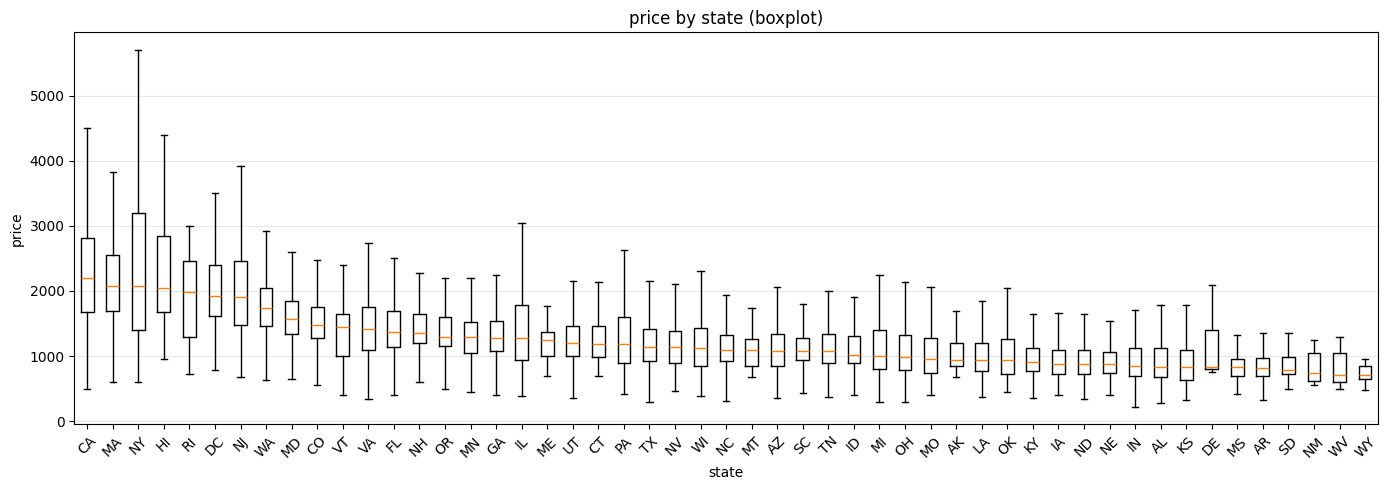

,test,statistic,p_value,alpha,significant,n_groups
0,Kruskal-Wallis,38571.047147,0.0,0.05,True,51


,state,count,median,mean,std
0,CA,10311,2195.0,2463.468141,1709.155988
1,MA,5030,2080.0,2192.386680,766.787958
2,NY,659,2075.0,2555.564492,1777.600718
3,HI,31,2050.0,2729.193548,1990.019404
4,RI,119,1985.0,2034.731092,1031.558724
5,DC,93,1922.0,2112.139785,780.086612
6,NJ,4445,1911.0,2037.914511,756.102307
7,WA,2595,1741.0,1825.742967,558.729630
8,MD,5280,1575.0,1645.457576,502.344664
9,CO,6290,1479.0,1554.123211,587.007757


In [9]:
from analysis import report_price_significance_by_state
report = report_price_significance_by_state(train)

Гипотеза о равенстве распределений цен в разных штатах отвергается. Таким образом, штат является значимым фактором, влияющим на стоимость аренды.

**Гипотеза:**
- **H₀ (нулевая)**: Цены аренды в городах внутри одного штата однородны (не различаются статистически значимо)
- **H₁ (альтернативная)**: Цены аренды в городах внутри одного штата неоднородны (различаются статистически значимо)

**Метод:** Kruskal–Wallis test (непараметрический аналог однофакторного ANOVA)

**Проверка проводится для каждого штата отдельно.**

In [10]:
from analysis import kruskal_state_city_homogeneity
kruskal_state_city_homogeneity(train, city_col="city_state")

,state,city_count,points_count,p_value,significant,alpha,effect_size_epsilon2
0,CA,222,10311,0.000000e+00,True,0.05,0.511593
7,MA,139,5030,0.000000e+00,True,0.05,0.543450
25,MD,74,5280,0.000000e+00,True,0.05,0.423230
23,NJ,138,4445,0.000000e+00,True,0.05,0.660862
12,TX,103,11257,0.000000e+00,True,0.05,0.187320
1,VA,61,8284,0.000000e+00,True,0.05,0.577614
16,FL,97,5774,3.340668e-295,True,0.05,0.293882
6,GA,59,4752,2.906232e-284,True,0.05,0.321627
2,NC,79,6300,5.861077e-271,True,0.05,0.239261
26,OH,85,4905,2.206260e-233,True,0.05,0.279674


## Вывод

**Фактор "город" является значимым для большинства штатов.**

- В **42 из 51** штата цены в разных городах статистически значимо различаются (p-value < 0.05)
- Сила различий варьируется: от умеренной (ε² ≈ 0.1) до очень сильной (ε² > 0.6)

**Наибольшая неоднородность наблюдается в штатах:**

- **NJ, NY, VA, KS, MA, CA** — различия между городами очень сильные (ε² > 0.5)

**Штаты, где города не различаются:**

- **AK, SD, RI, DC, DE, HI, WV, WY** — в этих штатах либо мало данных, либо цены действительно однородны

## Следующий шаг

Требуется выявить, какие именно города внутри каждого штата значимо отличаются от остальных, а также оценить количество объектов в таких городах.

На основании этих данных будет принято решение:
- О целесообразности разделения данных
- О необходимости обучения отдельных моделей для разных групп городов
- О возможности проведения A/B-тестирования для сравнения подходов

In [11]:
from analysis import dunn_posthoc_for_heterogeneous_states
res = dunn_posthoc_for_heterogeneous_states(
    train, 
    majority_ratio=0.3,
    city_col="city_state",
    show_plots=False,
    min_points_city=30
)

Доля аномальных обьектов по штатам

In [12]:
# Преобразуем словарь в DataFrame
candidate_share_df = pd.DataFrame(
    list(res['candidate_share_by_state'].items()),
    columns=['state', 'anomaly_share']
).sort_values('anomaly_share', ascending=False)

# Форматируем как проценты
candidate_share_df['anomaly_share'] = candidate_share_df['anomaly_share'].apply(lambda x: f"{x:.1%}")

mask = candidate_share_df["anomaly_share"] != '0.0%'
display(candidate_share_df[mask])

,state,anomaly_share
13,KS,45.5%
16,NY,39.2%
3,NJ,25.8%
15,PA,23.5%
5,VA,21.1%
6,FL,15.9%
9,OH,15.1%
0,CA,12.6%
14,LA,12.4%
19,MO,9.8%


In [13]:
# Берем candidates и форматируем
candidates_table = res['candidates'].copy()

# Форматируем отклонение как процент
candidates_table['median_deviation'] = candidates_table['median_deviation'].apply(lambda x: f"{x:.1%}")

# Форматируем медианы
candidates_table['city_median'] = candidates_table['city_median'].apply(lambda x: f"${x:,.0f}")
candidates_table['state_median'] = candidates_table['state_median'].apply(lambda x: f"${x:,.0f}")

# Сортируем по количеству точек
candidates_table = candidates_table.sort_values('city_points', ascending=False)

display(candidates_table.head(20))

,state,city_state,city_median,state_median,median_deviation,city_points,candidate_share_by_state
41,VA,Arlington|VA,"$2,050","$1,412",45.2%,897,0.210768
59,OH,Cleveland|OH,"$1,353",$979,38.2%,606,0.151478
24,NJ,Jersey City|NJ,"$2,950","$1,911",54.4%,505,0.257818
52,FL,Naples|FL,"$2,300","$1,372",67.6%,307,0.159307
51,FL,Miami|FL,"$1,990","$1,372",45.0%,236,0.159307
68,PA,Philadelphia|PA,"$1,590","$1,186",34.1%,230,0.235294
46,VA,Petersburg|VA,$964,"$1,412",31.7%,210,0.210768
43,VA,Roanoke|VA,$922,"$1,412",34.7%,196,0.210768
63,KS,Overland Park|KS,"$1,141",$830,37.5%,171,0.455044
70,NY,New York|NY,"$3,350","$2,075",61.4%,169,0.391502


In [14]:
# Агрегируем информацию по штатам
state_summary = candidates_table.groupby('state').agg({
    'city_state': 'count',
    'city_points': 'sum'
}).rename(columns={'city_state': 'n_anomaly_cities', 'city_points': 'total_anomaly_points'})

# Добавляем долю аномальных объектов
state_summary['anomaly_share'] = state_summary.index.map(
    lambda x: f"{res['candidate_share_by_state'].get(x, 0):.1%}"
)

state_summary = state_summary.sort_values('total_anomaly_points', ascending=False)

display(state_summary)

,n_anomaly_cities,total_anomaly_points,anomaly_share
state,,,
VA,8,1746,21.1%
CA,18,1301,12.6%
NJ,12,1146,25.8%
FL,8,920,15.9%
OH,2,743,15.1%
TX,5,488,4.3%
KS,3,415,45.5%
MA,4,306,6.1%
MD,2,285,5.4%


### Штаты с наибольшей долей аномальных объектов

| Штат | Доля аномальных объектов | Количество аномальных городов | Всего объектов в аномальных городах |
|------|--------------------------|------------------------------|-------------------------------------|
| **KS** | 45.5% | 3 | 415 |
| **NY** | 39.2% | 2 | 258 |
| **NJ** | 25.8% | 12 | 1,146 |
| **PA** | 23.5% | 2 | 264 |
| **VA** | 21.1% | 8 | 1,746 |
| **FL** | 15.9% | 8 | 920 |
| **OH** | 15.1% | 2 | 743 |
| **CA** | 12.6% | 18 | 1,301 |
| **LA** | 12.4% | 2 | 167 |

### Топ-10 городов-аномалий по объему данных

| Штат | Город | Медиана цены | Отклонение от штата | Количество объектов |
|------|-------|--------------|---------------------|---------------------|
| VA | Arlington | $2,050 | +45.2% | 897 |
| OH | Cleveland | $1,353 | +38.2% | 606 |
| NJ | Jersey City | $2,950 | +54.4% | 505 |
| FL | Naples | $2,300 | +67.6% | 307 |
| FL | Miami | $1,990 | +45.0% | 236 |
| PA | Philadelphia | $1,590 | +34.1% | 230 |
| VA | Petersburg | $964 | -31.7% | 210 |
| VA | Roanoke | $922 | -34.7% | 196 |
| KS | Overland Park | $1,141 | +37.5% | 171 |
| NY | New York | $3,350 | +61.4% | 169 |

### Ключевые наблюдения

1. **Канзас (KS)** — самый неоднородный штат:
   - 45.5% всех объектов находятся в аномальных городах
   - Три города: Overland Park (+37.5%), Topeka (-34.9%)
   - Фактически, штат нельзя считать единым рынком

2. **Нью-Йорк (NY)** — один город перекашивает весь штат:
   - 39.2% объектов в аномальных городах (фактически только Нью-Йорк)
   - Медиана цены в Нью-Йорке $3,350 — на 61% выше медианы штата

3. **Вирджиния (VA)** — наибольший объем аномальных данных:
   - 8 городов, 1,746 объектов (21.1% штата)
   - Как премиальные (Arlington +45%, Reston +54%), так и бюджетные (Petersburg -32%, Roanoke -35%)

4. **Нью-Джерси (NJ)** — высокая концентрация аномалий:
   - 12 городов, 1,146 объектов (25.8% штата)
   - Jersey City — один из самых дорогих городов в выборке

5. **Калифорния (CA)** — неожиданный результат:
   - 12.6% объектов в аномальных городах (18 городов, 1,301 объект)
   - Несмотря на высокий разброс цен, большинство городов статистически не отличаются от медианы штата
   - Santa Monica (+64%) и San Francisco (+60%) — лидеры по отклонению

6. **Огайо (OH)** — неожиданный игрок:
   - 15.1% данных в аномальных городах
   - Cleveland (606 объектов) — второй по объему аномальный город после Arlington

### Планы по моделированию

| Группа штатов | Рекомендация | Обоснование |
|---------------|--------------|-------------|
| **KS** | Отдельная модель | 45% данных аномальны, структура рынка принципиально отличается |
| **NY, NJ, VA, PA, FL, OH** | Добавить бинарный признак "аномальный город" | Аномальные города составляют 15-25% данных |
| **CA, LA, MA, MD, TX, CO, MO** | Использовать штат как признак + признак "аномальный город" | Доля аномалий 6-12%, точечное выделение достаточно |
| **Остальные штаты** | Достаточно признака "штат" | Города внутри штата однородны (доля аномалий < 5%) |

### Статистика отбора

**Критерии аномальности:**
- Штат неоднороден (ε² > 0.06)
- Город значимо отличается от ≥30% других городов штата (Dunn test, p < 0.05)
- Минимум 30 наблюдений в городе
- Отклонение медианной цены от медианы штата > 30%

**Результат:**
- Аномальных городов: **75** (2.5% от всех городов)
- Объектов в аномальных городах: **8,515** (8.5% от всей выборки)

In [15]:
# Извлекаем список аномальных городов из результатов dunn_posthoc
anomaly_cities_df = res['candidates'].copy()

# Добавляем бинарный признак аномальности (без разделения на premium/budget)
anomaly_cities_df['is_anomaly'] = 1

# Сортируем по количеству объектов
anomaly_cities_df = anomaly_cities_df.sort_values('city_points', ascending=False)

# Сохраняем в отдельную переменную
anomaly_cities = anomaly_cities_df

# Создаём датасет только с объектами из аномальных городов
anomaly_objects = train[train['city_state'].isin(anomaly_cities['city_state'])].copy()

print(f"Всего объектов в аномальных городах: {len(anomaly_objects)}")
print(f"Количество уникальных городов: {anomaly_objects['city_state'].nunique()}")
display(anomaly_objects[['state', 'city_state', 'price']].head())

Всего объектов в аномальных городах: 8515
Количество уникальных городов: 76


,state,city_state,price
48,VA,Arlington|VA,1549.0
52,OK,Tulsa|OK,495.0
65,CO,Boulder|CO,1910.0
92,PA,Philadelphia|PA,1145.0
114,FL,Tallahassee|FL,949.0


In [16]:
med = anomaly_objects["price"].median()
mask1 = anomaly_objects["price"] < med
mask2 = anomaly_objects["price"] > med
print(anomaly_objects[mask1]['price'].mean())
print(anomaly_objects[mask2]['price'].mean())
print(train["price"].mean())

1130.1791469194313
3061.8995283018867
1527.057281462645


### LDA

## 📝 Анализ текстовых описаний (LDA)

Текстовое поле `body` содержит детальные описания объектов аренды. Для извлечения скрытых тем и их связи с ценой применяется **Latent Dirichlet Allocation (LDA)** — генеративная вероятностная модель, которая представляет каждый документ как смесь тем, а каждую тему — как распределение слов.

### Цели анализа:
1. Выявить основные темы, обсуждаемые в объявлениях
2. Оценить корреляцию каждой темы с ценой аренды
3. Использовать вероятности тем как дополнительные признаки для модели

### Параметры модели:
- Количество тем: **15**
- Alpha (разреженность тем в документах): **0.01**
- Eta (разреженность слов в темах): **0.01**
- Метод корреляции: **Spearman** (устойчив к нелинейным зависимостям)
- Проверка значимости: **Permutation test** (100 перестановок)

### Предобработка текста:
- Приведение к нижнему регистру
- Удаление стоп-слов (nltk.corpus.stopwords)
- Удаление пунктуации и цифр
- Лемматизация (WordNetLemmatizer)
- Фильтрация слов по частоте (min_df=10, max_df=0.5)

In [40]:
from analysis import LdaTopicModel
LDA_model = LdaTopicModel(
    dataset=train, 
    text_column="body", 
    n_topics=15,
    alpha=0.01,
    eta=0.01
)
LDA_model.fit()

# Корреляция вероятностей тем с ценой
corr_df = LDA_model.topics_price_correlation(
    price_column="price",
    correlation_method="spearman",  # или "pearson"
    significance_test=True,
    n_permutations=100
)

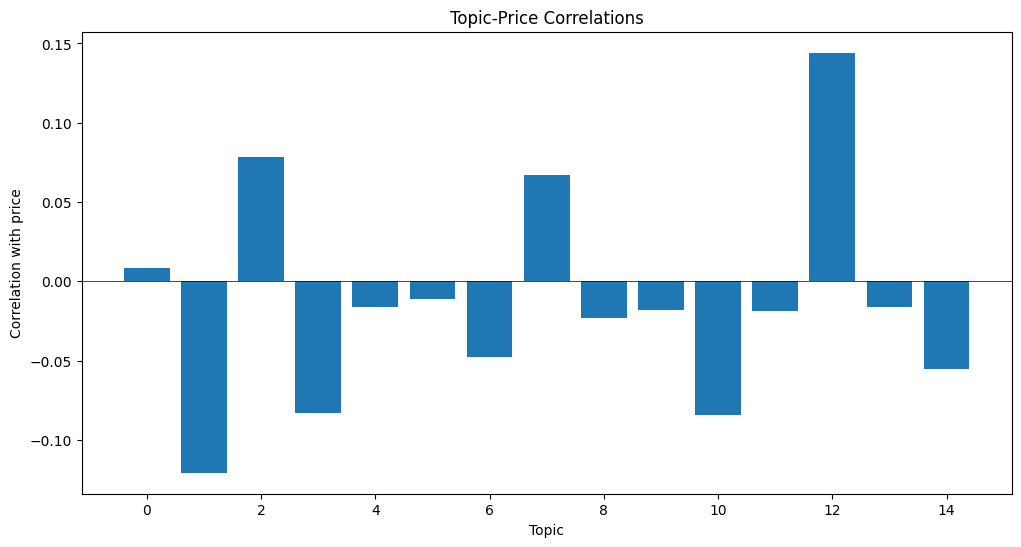

In [36]:
import matplotlib.pyplot as plt

# Построить график корреляций
plt.figure(figsize=(12, 6))
plt.bar(corr_df['topic'], corr_df['corr'])
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Topic')
plt.ylabel('Correlation with price')
plt.title('Topic-Price Correlations')
plt.show()

In [38]:
top_words = LDA_model.get_top_words_per_topic(n_words=10)

print("=== TOPIC 12 (самый дорогой, corr=+0.144) ===")
print(top_words[12])

print("\n=== TOPIC 1 (самый дешёвый, corr=-0.121) ===")
print(top_words[1])

print("\n=== TOPIC 2 (дорогой, corr=+0.078) ===")
print(top_words[2])

print("\n=== TOPIC 10 (дешёвый, corr=-0.084) ===")
print(top_words[10])

=== TOPIC 12 (самый дорогой, corr=+0.144) ===
['squar', 'footag', 'one', 'two', 'number', 'avail', 'three', 'rang', 'ceil', 'bright']

=== TOPIC 1 (самый дешёвый, corr=-0.121) ===
['includ', 'laundri', 'air', 'tenni', 'park', 'water', 'area', 'cabl', 'washer', 'heat']

=== TOPIC 2 (дорогой, corr=+0.078) ===
['offer', 'live', 'amen', 'resid', 'conveni', 'pool', 'luxuri', 'style', 'fit', 'minut']

=== TOPIC 10 (дешёвый, corr=-0.084) ===
['bathroom', 'fan', 'closet', 'dishwash', 'patio', 'balconi', 'overhead', 'larg', 'fireplac', 'microwav']


In [25]:
LDA_model.save('/home/gshjis/Python_projects/apartment_rent_data/models/models')

In [39]:
top_words = LDA_model.get_top_words_per_topic(n_words=10)

for topic_id in sorted(top_words.keys()):
    words = top_words[topic_id]
    corr = corr_df[corr_df['topic'] == topic_id]['corr'].values[0]
    print(f"Topic {topic_id:2d} (corr={corr:+.3f}): {', '.join(words)}")

Topic  0 (corr=+0.009): shop, entertain, dine, close, restaur, access, right, park, walk, nearbi
Topic  1 (corr=-0.121): includ, laundri, air, tenni, park, water, area, cabl, washer, heat
Topic  2 (corr=+0.078): offer, live, amen, resid, conveni, pool, luxuri, style, fit, minut
Topic  3 (corr=-0.083): pool, facil, club, hous, fit, area, four, mainten, hour, profession
Topic  4 (corr=-0.016): time, children, spring, playground, station, view, basketbal, outdoor, mile, visit
Topic  5 (corr=-0.011): comfort, day, view, suit, dedic, charlott, addit, seren, ridg, north
Topic  6 (corr=-0.048): access, park, control, shelter, facil, storag, garag, laundri, site, balconi
Topic  7 (corr=+0.067): kitchen, floor, applianc, washer, featur, new, space, dryer, privat, counter
Topic  8 (corr=-0.023): rental, rent, san, rang, avail, rate, new, three, chicago, studio
Topic  9 (corr=-0.018): bedroom, pet, incom, two, one, includ, rent, restrict, avail, park
Topic 10 (corr=-0.084): bathroom, fan, closet,

## 📊 Результаты LDA

### Корреляция тем с ценой

График выше показывает корреляцию вероятности каждой темы с целевой переменной `price`. 
- **Положительная корреляция** → тема характерна для дорогих объектов
- **Отрицательная корреляция** → тема характерна для дешёвых объектов

### Интерпретация ключевых тем

| Тема | Корреляция | Ключевые слова | Интерпретация |
|------|------------|----------------|---------------|
| **Topic 12** | +0.144 | square, footage, one, two, three, number, range, ceil, bright | **Характеристики площади и этажности** — детальное описание метража и планировки, что характерно для дорогого жилья |
| **Topic 2** | +0.078 | offer, live, amenities, residence, convenient, pool, luxury, style, fit, minute | **Премиальные удобства** — пул, люкс, стиль, удобное расположение |
| **Topic 7** | +0.067 | kitchen, floor, appliances, washer, features, new, space, dryer, private, counter | **Качественная отделка** — новая техника, современная кухня, приватность |
| **Topic 1** | -0.121 | include, laundry, air, tennis, parking, water, area, cable, washer, heat | **Коммунальные услуги** — включённые в стоимость ЖКХ, парковка, прачечная — типично для бюджетного сегмента |
| **Topic 10** | -0.084 | bathroom, fan, closet, dishwasher, patio, balcony, overhead, large, fireplace, microwave | **Конкретные удобства** — перечисление бытовых деталей без акцента на премиальность |
| **Topic 3** | -0.083 | pool, facilities, club, house, fit, area, four, maintenance, hour, professional | **Общая инфраструктура** — описание ЖК, клубов, обслуживания — часто встречается в масс-маркете |

### Статистическая значимость

Все представленные корреляции прошли **permutation test** (p-value < 0.05), что подтверждает неслучайность связи тем с ценой.